Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

In [ ]:
from setup import *

# ER LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.46,11
,3000,0,0.41,7
,3000,0,0.49,7
,3000,0,0.42,11


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -559.63    39.40
p_loo       26.14        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



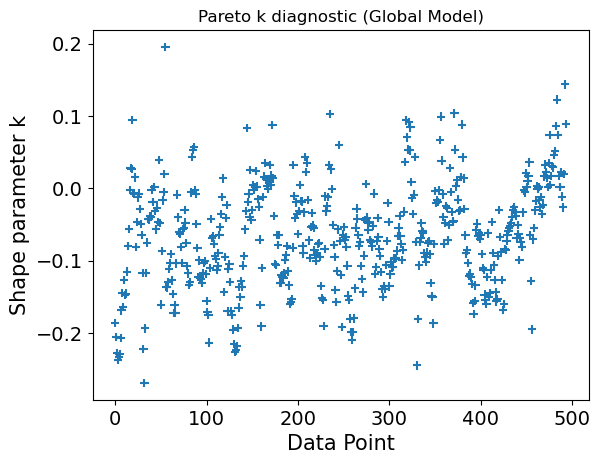

In [4]:
with pm.Model() as ER_LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH- -> COOH* + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.25, sigma=0.15, upper=0.0)
    deltaG4_0 = pm.TruncatedNormal('deltaG4_0', mu=-0.30, sigma=0.25, upper=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=2.5, beta=7.5)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.75, sigma=0.05) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.75, sigma=0.05) 

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_model = pt.logaddexp(log_rate_ER, log_rate_LH)
    log_rate = observables(log_rate_model)

trace_ER_LH_2, loo_ER_LH_2 = fit_and_evaluate(ER_LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
Gact2_ER_0  0.748  0.001   0.747    0.749        0.0      0.0    1491.0    2138.0    1.0
Gact2_LH_0  0.769  0.006   0.757    0.781        0.0      0.0    1520.0    1350.0    1.0
deltaG1_0  -0.122  0.002  -0.126   -0.118        0.0      0.0    1461.0    1951.0    1.0
deltaG4_0  -0.025  0.009  -0.040   -0.008        0.0      0.0    1362.0    1895.0    1.0
beta_2      0.268  0.007   0.255    0.280        0.0      0.0    1172.0    2052.0    1.0


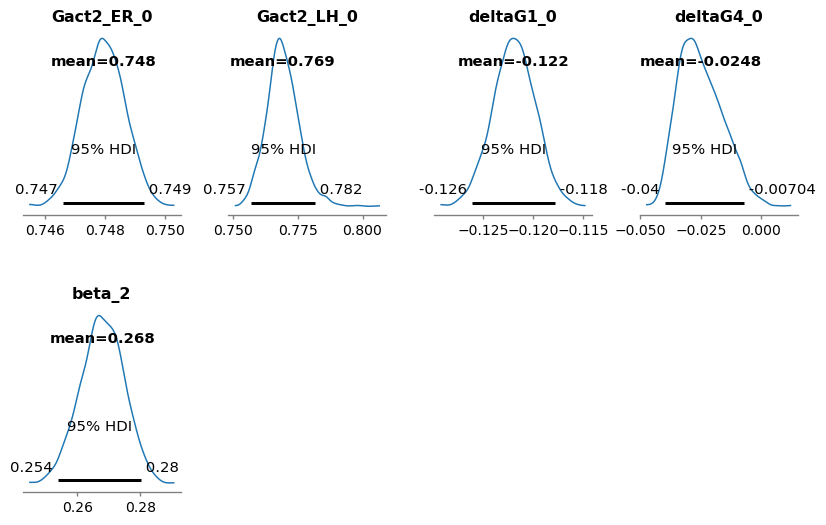

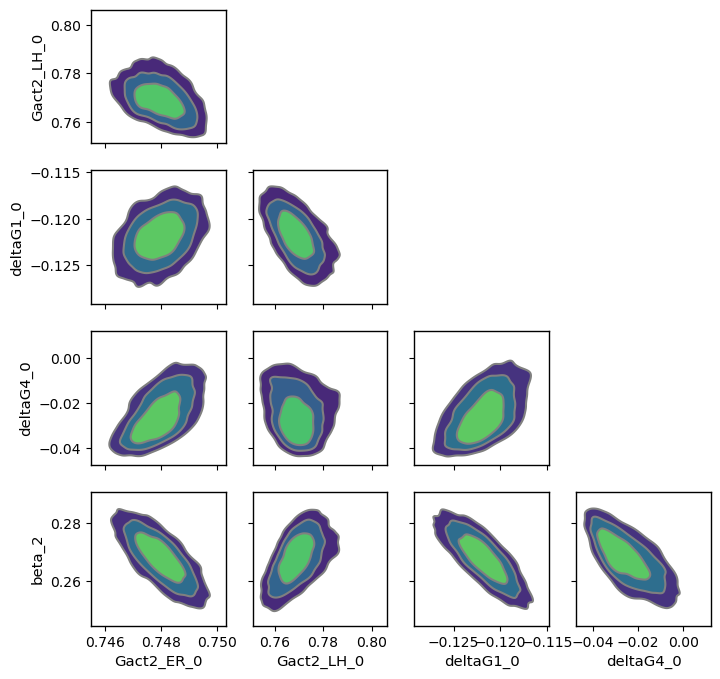

Sampling: [rate]


rate: 0.808


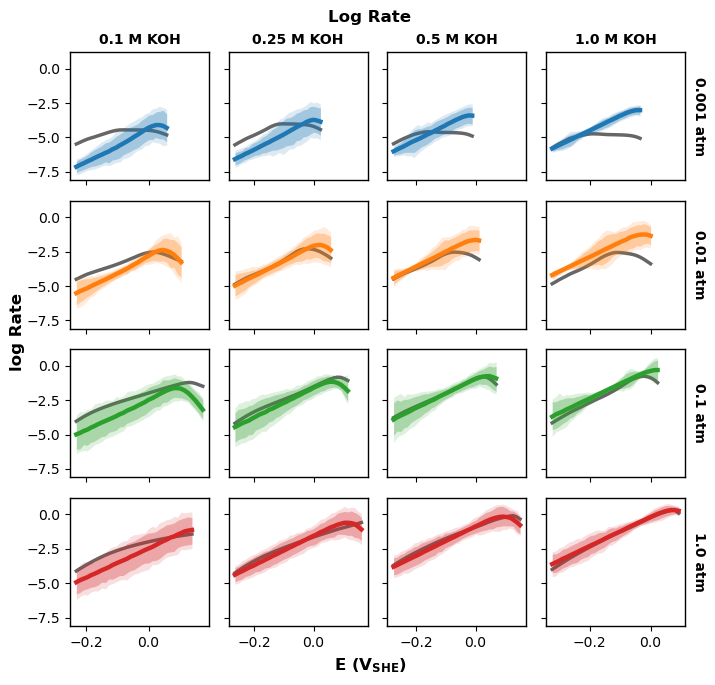

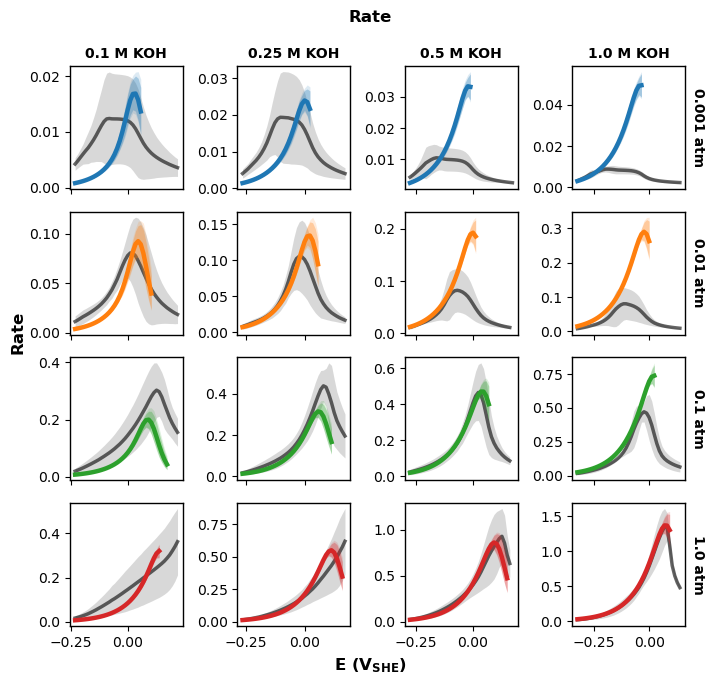

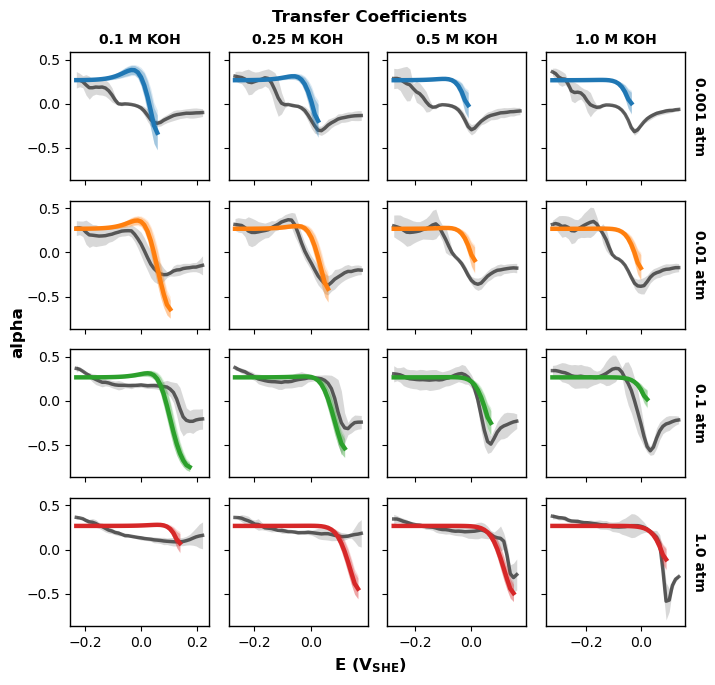

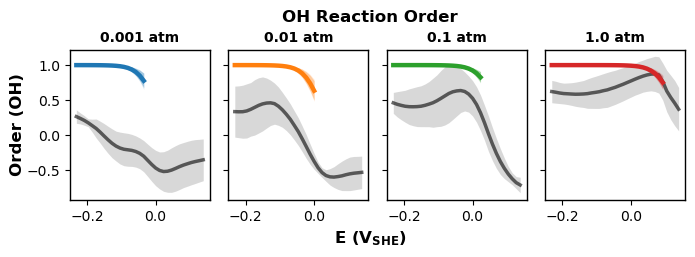

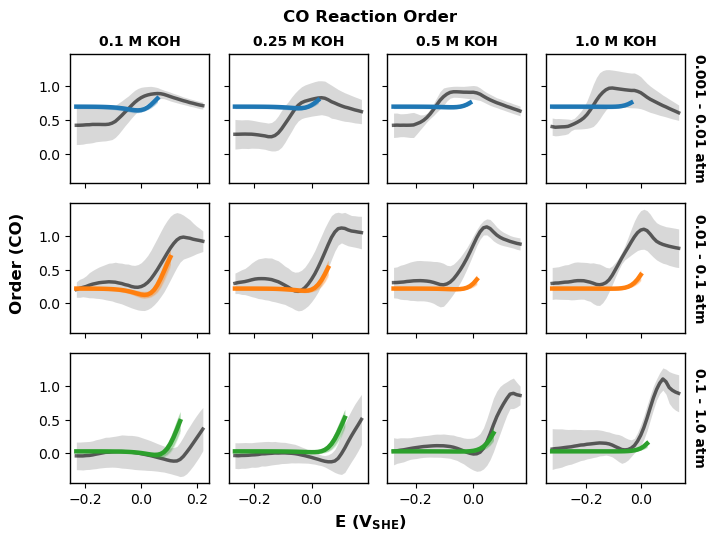

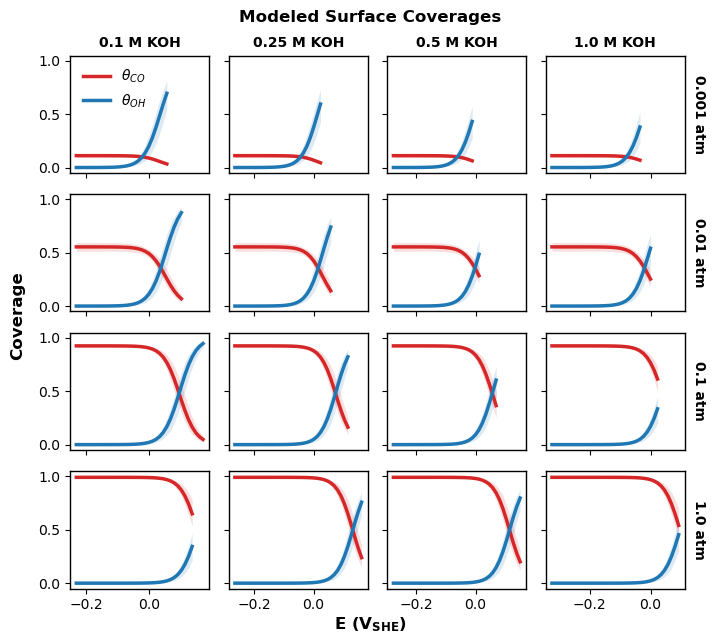

In [5]:
ppc_ER_LH_2 = plot_posteriors(trace_ER_LH_2, ER_LH_2, plot_target)
plot_model_fits(trace_ER_LH_2, ppc_ER_LH_2); plot_coverages(trace_ER_LH_2)

# ER 2 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.26,31
,3000,0,0.22,7
,3000,0,0.28,47
,3000,0,0.22,31


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -547.22    38.11
p_loo       12.99        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      493   99.8%
   (0.70, 1]   (bad)         1    0.2%
   (1, Inf)   (very bad)    0    0.0%



c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


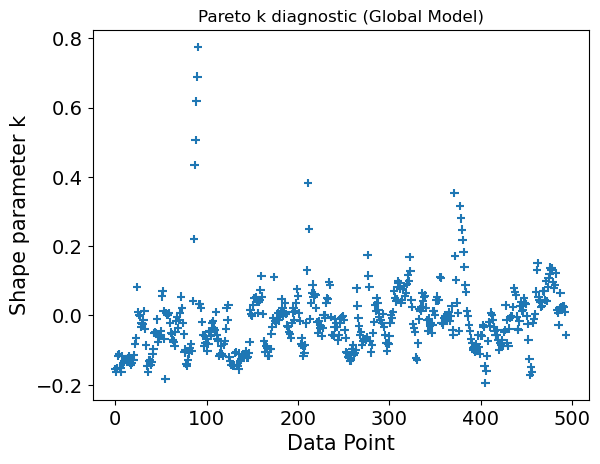

In [6]:
with pm.Model() as ER_2_3:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- <-> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.20, sigma=0.15, upper=0.0)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) 
    deltaG2_ER_0 = pm.Normal('deltaG2_ER_0', mu=-0.45, sigma=0.05) 
    beta_2 = pm.Beta('beta_2', alpha=10.0, beta=30.0)
    beta_3 = pm.Beta('beta_3', alpha=20.0, beta=20.0)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.05)
    delta_Gact = pm.TruncatedNormal('delta_Gact', mu=-0.10, sigma=0.02, upper=0.0)
    Gact3_0 = pm.Deterministic('Gact3_0', Gact2_0 + delta_Gact)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2_ER = deltaG2_ER_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in

    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_k2_ER + term_CO + np.log(C_KOH_in) - pt.logaddexp(log_k2_ER - log_K2_ER, log_k3 + np.log(C_KOH_in))
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0) 

    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_ER_2_3, loo_ER_2_3 = fit_and_evaluate(ER_2_3, target_accept=0.95)

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0     0.077  0.026   0.035    0.121      0.001    0.002    1760.0    1049.0    1.0
deltaG2_ER_0 -0.454  0.042  -0.535   -0.384      0.001    0.001    3827.0    2793.0    1.0
Gact2_0       0.749  0.001   0.747    0.750      0.000    0.000    1809.0    1613.0    1.0
deltaG1_0    -0.113  0.002  -0.118   -0.109      0.000    0.000    1618.0    1879.0    1.0
beta_2        0.222  0.008   0.206    0.235      0.000    0.000    1540.0    1952.0    1.0
beta_3        0.610  0.044   0.524    0.689      0.001    0.001    1032.0    1093.0    1.0
delta_Gact   -0.105  0.013  -0.128   -0.080      0.000    0.000     982.0     962.0    1.0
Gact3_0       0.643  0.013   0.619    0.666      0.000    0.000     979.0    1010.0    1.0


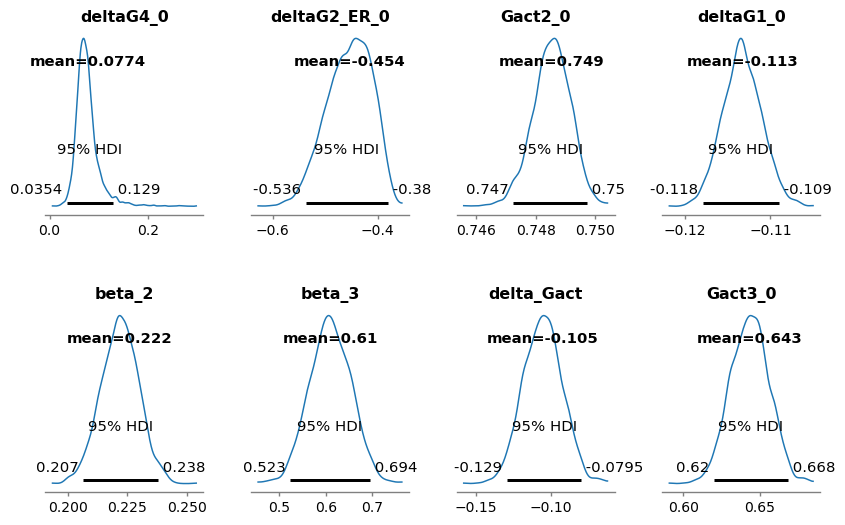

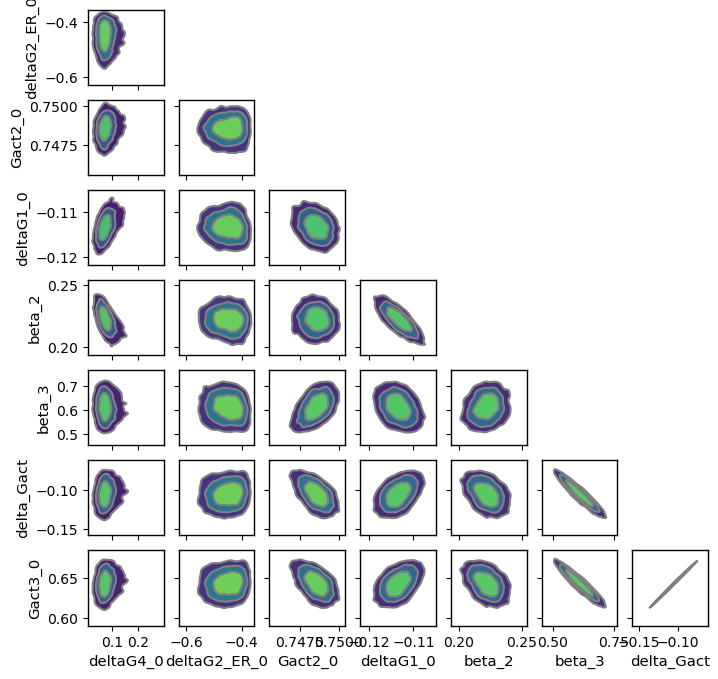

Sampling: [rate]


rate: 0.821


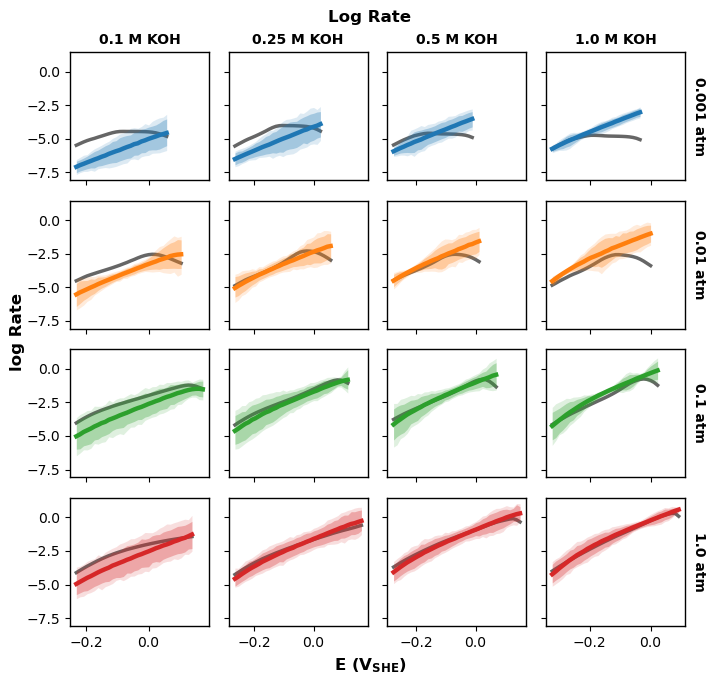

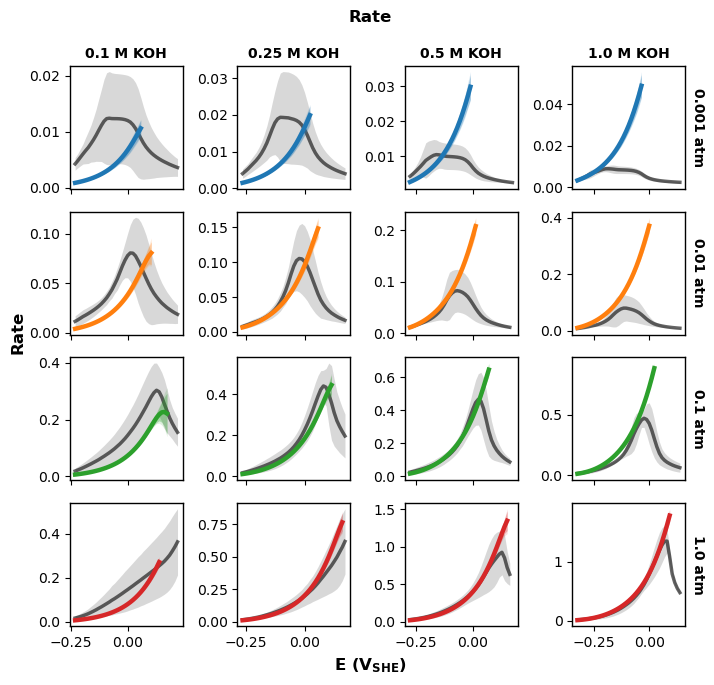

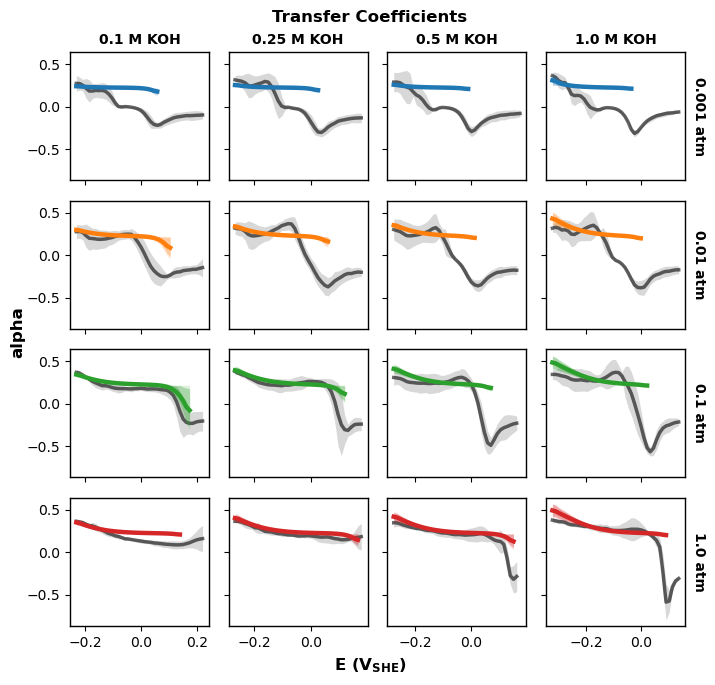

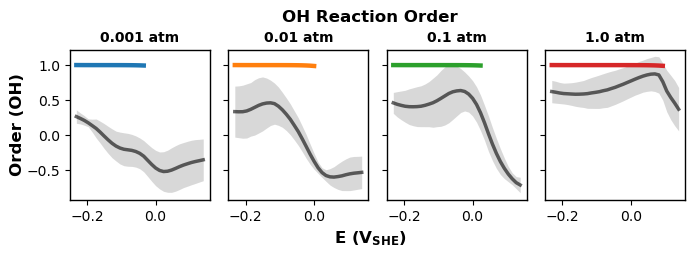

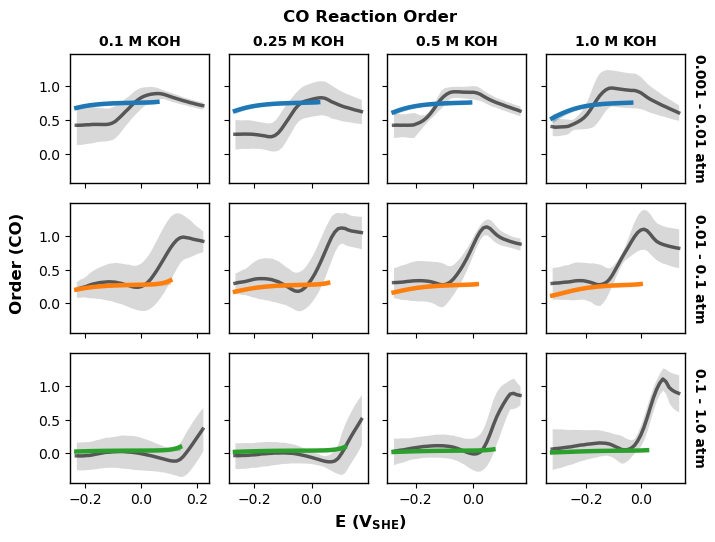

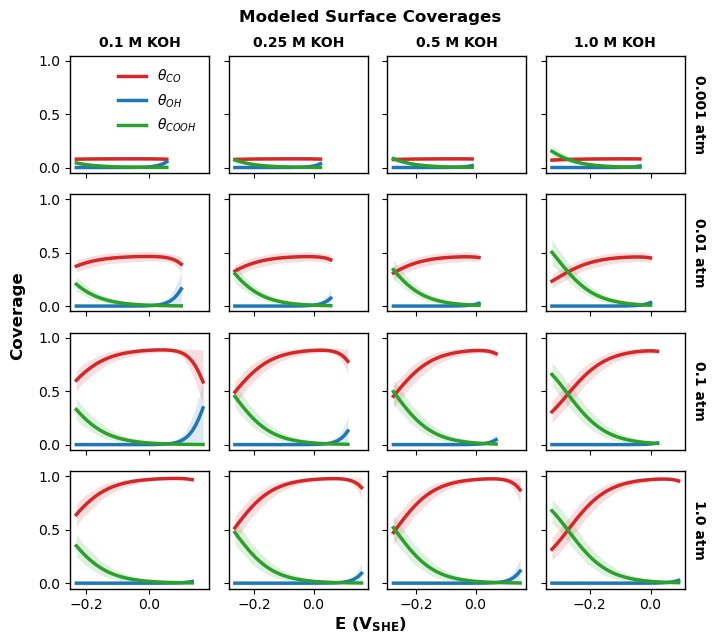

In [7]:
ppc_ER_2_3 = plot_posteriors(trace_ER_2_3, ER_2_3, plot_target)
plot_model_fits(trace_ER_2_3, ppc_ER_2_3); plot_coverages(trace_ER_2_3)

# LH 2 3

# Comparison

         rank    elpd_loo      p_loo  elpd_diff   weight         se        dse  warning scale
ER_2_3      0 -547.217814  12.985190   0.000000  0.50824  38.110855   0.000000     True   log
ER_LH_2     1 -559.628511  26.143278  12.410696  0.49176  39.395954  15.965482    False   log


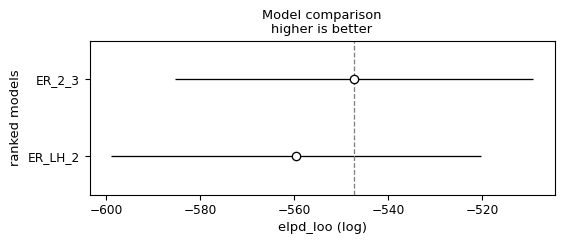

In [10]:
comparison_dict = {
    "ER_LH_2": loo_ER_LH_2,
    "ER_2_3": loo_ER_2_3,
    # "LH_2_3": loo_LH_2_3,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()